# Continued EDA

## Table of Contents

## Set Up

In [328]:
# Standard imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objs as go

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Lasso, Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, precision_score, recall_score, roc_curve, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from tempfile import mkdtemp

In [187]:
# show all dataframe columns
pd.set_option('display.max_columns', None)
# set matplotlib global settings eg. figsize
plt.rcParams['figure.figsize'] = (8.0, 6.0)

In [188]:
# Import hotel_clean_df
clean_df = pd.read_csv('clean_df')

#Import cxl_by_date
cxl_by_date = pd.read_csv('cxl_by_date')

#Import demand_by_date
demand_by_date = pd.read_csv('demand_by_date')

In [189]:
clean_df.head(5)
#cxl_by_date.head(5)
#demand_by_date.head(5)

,hotel,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,day_demand
0,Resort Hotel,0,342,27,0,0,2,0,0,1,Direct,Direct,0,0,0,3,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,122
1,Resort Hotel,0,737,27,0,0,2,0,0,1,Direct,Direct,0,0,0,4,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,122
2,Resort Hotel,0,7,27,0,1,1,0,0,1,Direct,Direct,0,0,0,0,No Deposit,0,0,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,122
3,Resort Hotel,0,13,27,0,1,1,0,0,1,Corporate,Corporate,0,0,0,0,No Deposit,1,0,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,122
4,Resort Hotel,0,14,27,0,2,2,0,0,1,Online TA,TA/TO,0,0,0,0,No Deposit,1,0,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-01,122


In [190]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_week_number        119390 non-null  int64  
 4   stays_in_weekend_nights         119390 non-null  int64  
 5   stays_in_week_nights            119390 non-null  int64  
 6   adults                          119390 non-null  int64  
 7   children                        119390 non-null  int64  
 8   babies                          119390 non-null  int64  
 9   meal                            119390 non-null  int64  
 10  market_segment                  119390 non-null  object 
 11  distribution_channel            119390 non-null  object 
 12  is_repeated_gues

In [191]:
#Converting date columns back to datetime
clean_df['arrival_date'] = pd.to_datetime(clean_df['arrival_date'])
clean_df['reservation_status_date'] = pd.to_datetime(clean_df['reservation_status_date'])

# Additional EDA

- Compare `market_segment` with `distribution_channel`. Are values the same? Can we drop one?
- Demand 
    - by `customer_type`
    - by `market_segment`/`distribution_channel`
- Cancellations
    - Total Cancellations
    - by `customer_type`
    - by `market_segment`/`distribution_channel`
- Booking Windows
    - Average `lead_time` of each reservation
    - `lead_time` by `customer_type`
    - `lead_time` by top 3 `market_segments`
- Cancellation Windows
    - How many days before arrival do cancellations occur? For `reservation_status` that are 'Canceled' how many days between `reservation_status_date` and `arrival_date`?
    - Cancellation window by `customer_type`
    - Cancellation window by `market_segment`


In [194]:
# Compare market_segment and distribution_channel
print(clean_df[['market_segment','distribution_channel']].value_counts(),'\n\n')
print(clean_df['market_segment'].value_counts(),'\n\n')
print(clean_df['distribution_channel'].value_counts())

market_segment  distribution_channel
Online TA       TA/TO                   56153
Offline TA/TO   TA/TO                   23946
Groups          TA/TO                   17111
Direct          Direct                  12276
Corporate       Corporate                4788
Groups          Direct                   1472
                Corporate                1228
Complementary   Direct                    576
Corporate       TA/TO                     335
Direct          TA/TO                     237
Aviation        Corporate                 227
Offline TA/TO   Corporate                 212
Corporate       Direct                    172
Online TA       GDS                       147
                Direct                    133
Direct          Corporate                  90
Complementary   Corporate                  89
                TA/TO                      78
Offline TA/TO   GDS                        45
Online TA       Corporate                  43
Offline TA/TO   Direct                     

The values "somewhat" overlap, however the market segment is the segmentation of the the guest type.  Whereas the distribution channel is the form in which the reservation was made.  These are indeed different and I will keep them separate.

## Additional Demand EDA:
- by Customer Type 
- by Demand by Market Segment

In [195]:
# Demand by customer_type
clean_df['customer_type'].value_counts(normalize=True) *100

customer_type
Transient          75.059050
Transient-Party    21.043638
Contract            3.414021
Group               0.483290
Name: proportion, dtype: float64

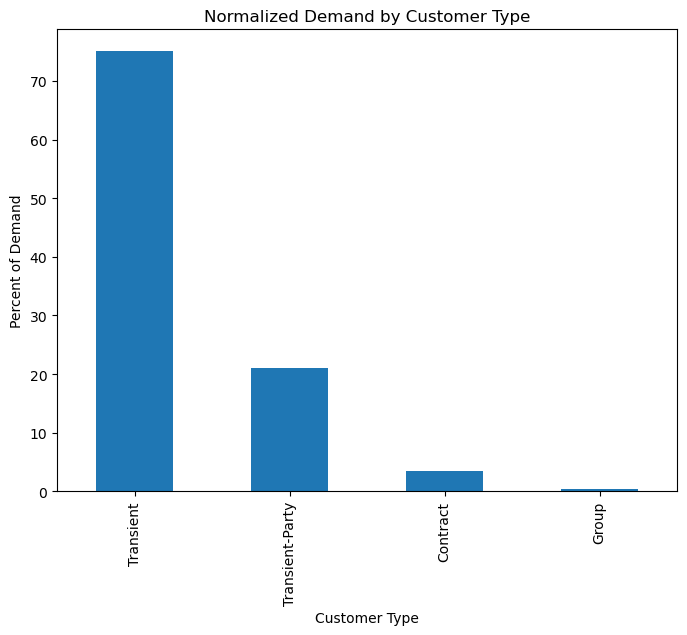

In [196]:
# Demand by customer_type
(clean_df['customer_type'].value_counts(normalize=True) * 100).plot(kind='bar')

plt.title('Normalized Demand by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Percent of Demand')
plt.show()


Looking at customer types, I want to combine the two Transient customer_types as well as removing reservations under the Group customer type since there is very few group reservations in this dataset.  Also, in my experience and understanding of Group demand, they are very different to transient demand and therefore I will focus primarily on transient demand only.

I will make these changes in the upcoming feature engineering section.

***


In [197]:
# Demand by market_segment
clean_df['market_segment'].value_counts(normalize=True) *100

market_segment
Online TA        47.304632
Offline TA/TO    20.285619
Groups           16.593517
Direct           10.558673
Corporate         4.435045
Complementary     0.622330
Aviation          0.198509
Undefined         0.001675
Name: proportion, dtype: float64

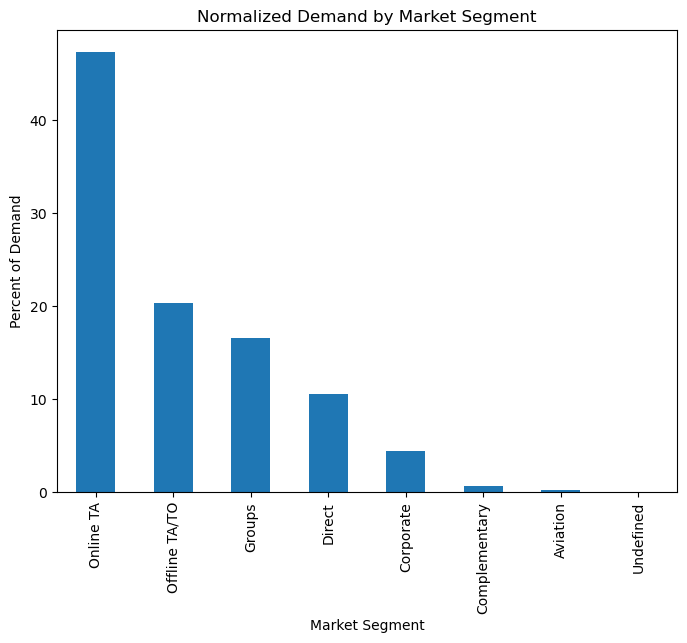

In [198]:
# Demand by market_segment
(clean_df['market_segment'].value_counts(normalize=True) * 100).plot(kind='bar')

plt.title('Normalized Demand by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Percent of Demand')
plt.show()


## Additional Cancellations EDA
- Total Cancellations
- by Market Segment 
- by Customer Type 

In [ ]:
# Total Cancellations
total_reservations = clean_df.shape[0]
total_cancelled = clean_df['is_canceled'].value_counts()[1]
total_cancel_pct = clean_df['is_canceled'].value_counts(normalize=True)[1]

print(f'Total Reservations: {total_reservations}')
print(f"Total Canceled Reservations: {total_cancelled}")
print(f"Percentage of Reservations Cancelled: {np.round(total_cancel_pct,4)*100}%")

Total Reservations: 119390
Total Canceled Reservations: 44224
Percentage of Reservations Cancelled: 37.04%


The cancellation percentage may initially feel high, however given my experience in the industry, it's not abnormal to see cancellation percentages this high because this value also includes date changes, no shows, and cancellations.

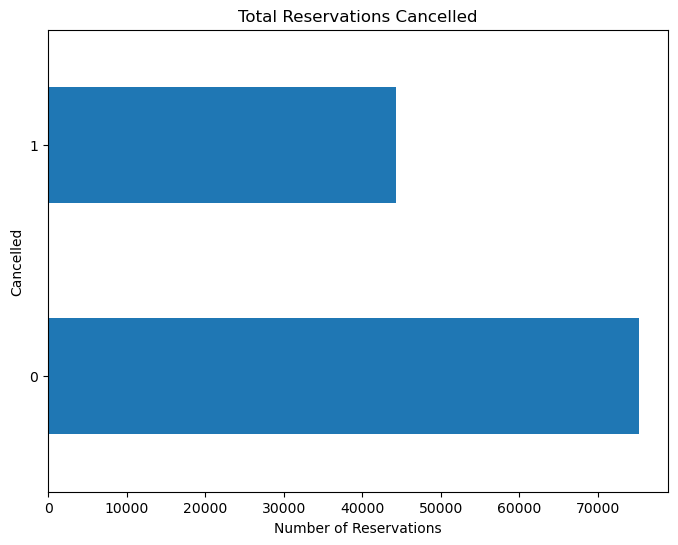

In [ ]:
# Total Cancellations
clean_df['is_canceled'].value_counts().plot(kind='barh')

plt.title('Total Reservations Cancelled')
plt.ylabel('Cancelled')
plt.xlabel('Number of Reservations')
plt.show()


In [199]:
# Creating a DF with market segments by cancellations
segmentation_cxl_df = clean_df.groupby(['market_segment', 'is_canceled']).size().unstack(fill_value=0)
segmentation_cxl_df

is_canceled,0,1
market_segment,,
Aviation,185,52
Complementary,646,97
Corporate,4303,992
Direct,10672,1934
Groups,7714,12097
Offline TA/TO,15908,8311
Online TA,35738,20739
Undefined,0,2


In [200]:
# Adding a cancellation percent to the dataframe
segmentation_cxl_df['cxl_percent'] = np.round(segmentation_cxl_df[1] / (segmentation_cxl_df[1] + segmentation_cxl_df[0])*100, 4)

In [201]:
# Sanity check
segmentation_cxl_df

is_canceled,0,1,cxl_percent
market_segment,,,
Aviation,185,52,21.9409
Complementary,646,97,13.0552
Corporate,4303,992,18.7347
Direct,10672,1934,15.3419
Groups,7714,12097,61.0620
Offline TA/TO,15908,8311,34.3160
Online TA,35738,20739,36.7211
Undefined,0,2,100.0000


## Question 0 : Unable to add the labels in the stacked bar plot for cancellation percentage

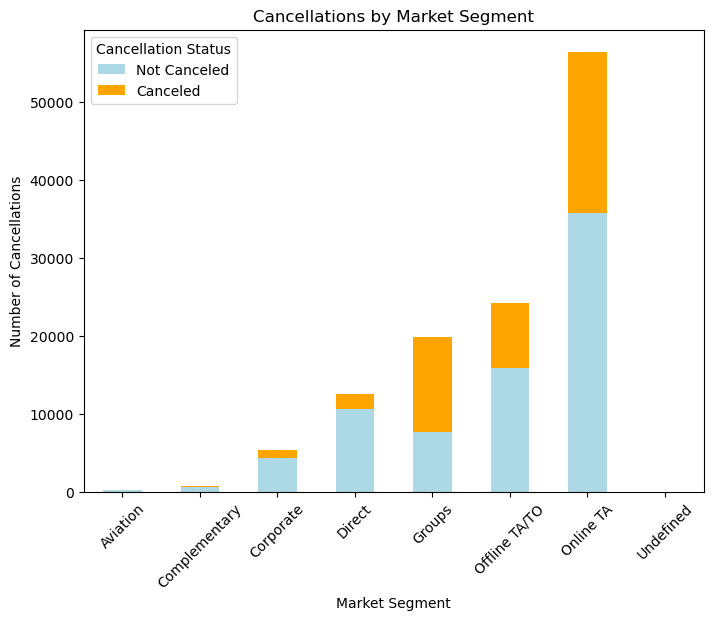

In [202]:
# Stacked Bar Plot for Cancellations by Market Segment
clean_df.groupby(['market_segment', 'is_canceled']).size().unstack(fill_value=0).plot(
    kind='bar', stacked=True,color=['lightblue', 'orange'])

#for index, seg in segmentation_cxl_df.iterrows():
#    plt.text(index, seg[0], f"{seg['cxl_percent']:.1f}%", ha='center', va='center', color='black', fontsize=10)

plt.title('Cancellations by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Cancellations')
plt.legend(title='Cancellation Status', labels=['Not Canceled', 'Canceled'])
plt.xticks(rotation=45)
plt.show()

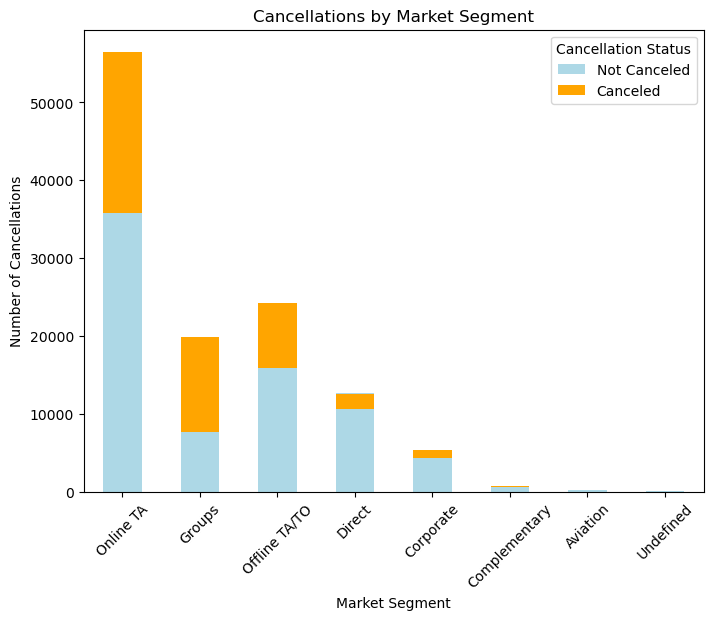

In [203]:
# Cancellations by Market Segment Plot
segmentation_cxl_df.sort_values(by=1, ascending=False).plot(
    kind='bar', stacked=True,color=['lightblue', 'orange'])

plt.title('Cancellations by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Cancellations')
plt.legend(title='Cancellation Status', labels=['Not Canceled', 'Canceled'])
plt.xticks(rotation=45)
plt.show()

In [204]:
# Cancellations by Customer Type
#clean_df[['is_canceled','customer_type']].value_counts()
clean_df.groupby('customer_type')['is_canceled'].value_counts()

customer_type    is_canceled
Contract         0               2814
                 1               1262
Group            0                518
                 1                 59
Transient        0              53099
                 1              36514
Transient-Party  0              18735
                 1               6389
Name: count, dtype: int64

In [205]:
# Creating a DF with customer type by cancellations
customer_cxl_df = clean_df.groupby(['customer_type', 'is_canceled']).size().unstack(fill_value=0)
customer_cxl_df

is_canceled,0,1
customer_type,,
Contract,2814,1262
Group,518,59
Transient,53099,36514
Transient-Party,18735,6389


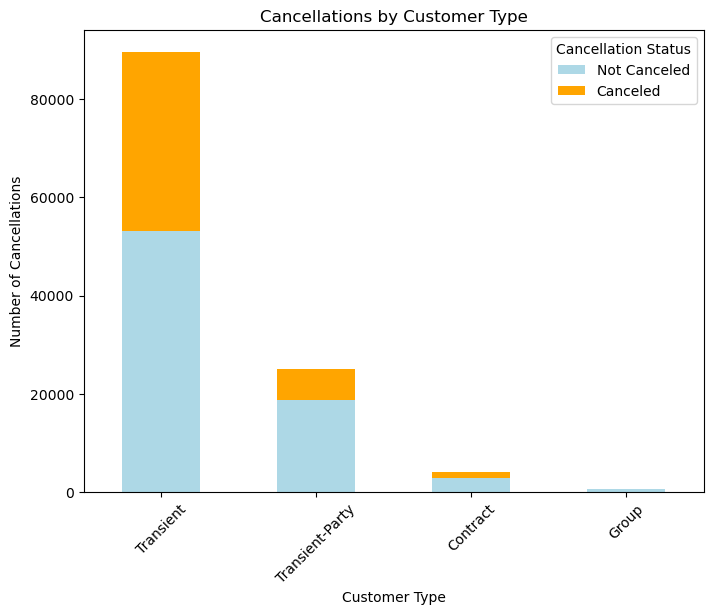

In [206]:
# Cancellations by Customer Type Plot
customer_cxl_df.sort_values(by=1, ascending=False).plot(
    kind='bar', stacked=True,color=['lightblue', 'orange'])

plt.title('Cancellations by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Number of Cancellations')
plt.legend(title='Cancellation Status', labels=['Not Canceled', 'Canceled'])
plt.xticks(rotation=45)
plt.show()

## TODO: Is it necessary to transform the market segment and customer type features so that I can see a breakdown by date with the date as the index?

## Booking Window EDA
- `lead_time` by `customer_type`

In [207]:
clean_df['lead_time'].describe()

count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

The average lead time for bookings are 104 days with the max being 737. That is booking a hotel over 2 years in advanced.

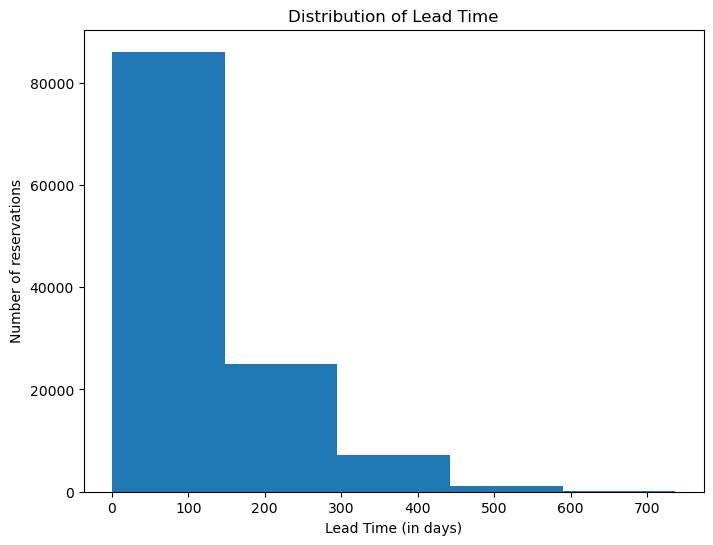

In [208]:
# Plot the distribution of the lead times
clean_df['lead_time'].plot(kind='hist', bins=5)
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time (in days)')
plt.ylabel('Number of reservations')
plt.show()


In [209]:
# Create lead time ranges 
lead_time_range = [
(None, 7, 'less than 7'),
(7, 14, 'between 7-14'),
(14, 30, 'between 14-30'),
(30, None, 'more than 30')    
]

In [210]:
for lower, upper, label in lead_time_range:
    if lower is None:
        count = clean_df[clean_df['lead_time'] < upper].shape[0]
    elif upper is None:
        count = clean_df[clean_df['lead_time'] >= lower].shape[0]
    else:
        count = clean_df[(clean_df['lead_time'] >= lower) & (clean_df['lead_time'] < upper)].shape[0]
    
    print(f"Number of reservations that booked {label} days in advance: {count}")

Number of reservations that booked less than 7 days in advance: 18415
Number of reservations that booked between 7-14 days in advance: 7392
Number of reservations that booked between 14-30 days in advance: 12240
Number of reservations that booked more than 30 days in advance: 81343


In [211]:
# # Identify the lead time ranges
# print(f"Number of reservations that booked less than 30 days in advanced: {clean_df[clean_df['lead_time']<=30].shape[0]}")
# print(f"Number of reservations that booked between 30-60 days in advanced: {clean_df[(clean_df['lead_time']>=30) & (clean_df['lead_time']<60)].shape[0]}")
# print(f"Number of reservations that booked between 60-90 days in advanced: {clean_df[(clean_df['lead_time']>=60) & (clean_df['lead_time']<90)].shape[0]}")
# print(f"Number of reservations that booked between 90-180 days in advanced: {clean_df[(clean_df['lead_time']>=90) & (clean_df['lead_time']<180)].shape[0]}")
# print(f"Number of reservations that booked between 180-365 days in advanced: {clean_df[(clean_df['lead_time']>=180) & (clean_df['lead_time']<365)].shape[0]}")
# print(f"Number of reservations that booked over 365+ days in advanced: {clean_df[clean_df['lead_time']>=365].shape[0]}")


In [212]:
# # Identify the lead time ranges
# print(f"Number of reservations that booked less than 7 days in advanced: {clean_df[clean_df['lead_time']<7].shape[0]}")
# print(f"Number of reservations that booked between 7-14 days in advanced: {clean_df[(clean_df['lead_time']>=7) & (clean_df['lead_time']<14)].shape[0]}")
# print(f"Number of reservations that booked between 14-30 days in advanced: {clean_df[(clean_df['lead_time']>=14) & (clean_df['lead_time']<30)].shape[0]}")
# print(f"Number of reservations that booked over 30+ days in advanced: {clean_df[clean_df['lead_time']>=30].shape[0]}")


In order to view the lead time by customer type and market segment, feature engineering will need to be completed to group the lead times into smaller buckets.

# Feature Engineering
1. Group `customer_type` Transient and Transient Party together
2. Isolate only Transient `customer_type`
3. Calculate and group Length of Stay into buckets
4. Remove `reservation_status` feature
5. One Hot Encoding for remaining categorical features

## Customer Type Feature Engineering
- Group Customer_Type Transient and Transient Party together
- Isolate only Transient customer_type

In [213]:
# Checking customer_type values
clean_df['customer_type'].value_counts()

customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

In [214]:
# Change all Transient-Party to be Transient
clean_df['customer_type'].replace('Transient-Party', 'Transient',inplace=True)

In [215]:
# Sanity Check
clean_df['customer_type'].value_counts()

customer_type
Transient    114737
Contract       4076
Group           577
Name: count, dtype: int64

In [216]:
clean_df.shape

(119390, 28)

In [217]:
# Drop all rows containing Contract or Group customer_type
clean_df = clean_df[clean_df['customer_type'] == 'Transient'].reset_index(drop=True)
clean_df

,hotel,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,day_demand
0,Resort Hotel,0,342,27,0,0,2,0,0,1,Direct,Direct,0,0,0,3,No Deposit,0,0,0,Transient,0.00,0,0,Check-Out,2015-07-01,2015-07-01,122
1,Resort Hotel,0,737,27,0,0,2,0,0,1,Direct,Direct,0,0,0,4,No Deposit,0,0,0,Transient,0.00,0,0,Check-Out,2015-07-01,2015-07-01,122
2,Resort Hotel,0,7,27,0,1,1,0,0,1,Direct,Direct,0,0,0,0,No Deposit,0,0,0,Transient,75.00,0,0,Check-Out,2015-07-02,2015-07-01,122
3,Resort Hotel,0,13,27,0,1,1,0,0,1,Corporate,Corporate,0,0,0,0,No Deposit,1,0,0,Transient,75.00,0,0,Check-Out,2015-07-02,2015-07-01,122
4,Resort Hotel,0,14,27,0,2,2,0,0,1,Online TA,TA/TO,0,0,0,0,No Deposit,1,0,0,Transient,98.00,0,1,Check-Out,2015-07-03,2015-07-01,122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114732,City Hotel,0,23,35,2,5,2,0,0,1,Offline TA/TO,TA/TO,0,0,0,0,No Deposit,1,0,0,Transient,96.14,0,0,Check-Out,2017-09-06,2017-08-30,89
114733,City Hotel,0,102,35,2,5,3,0,0,1,Online TA,TA/TO,0,0,0,0,No Deposit,1,0,0,Transient,225.43,0,2,Check-Out,2017-09-07,2017-08-31,134
114734,City Hotel,0,34,35,2,5,2,0,0,1,Online TA,TA/TO,0,0,0,0,No Deposit,1,0,0,Transient,157.71,0,4,Check-Out,2017-09-07,2017-08-31,134
114735,City Hotel,0,109,35,2,5,2,0,0,1,Online TA,TA/TO,0,0,0,0,No Deposit,1,0,0,Transient,104.40,0,0,Check-Out,2017-09-07,2017-08-31,134


## Length of Stay Feature Engineering 
- Calculate and group Length of Stay into buckets

In [218]:
clean_df[['stays_in_week_nights', 'stays_in_weekend_nights']]

,stays_in_week_nights,stays_in_weekend_nights
0,0,0
1,0,0
2,1,0
3,1,0
4,2,0
...,...,...
114732,5,2
114733,5,2
114734,5,2
114735,5,2


In [219]:
# Add stays_in_weekend_nights + stays_in_week_nights
clean_df['los'] = clean_df['stays_in_week_nights'] + clean_df['stays_in_weekend_nights']

In [220]:
# Sanity check
clean_df['los'].value_counts().head(10)

los
2     26499
3     26457
1     20535
4     16960
7      7782
5      7574
6      3742
8      1119
10      920
9       782
Name: count, dtype: int64

Looking at the value counts for length of stay, over 90,000 of the 114,000 reservations stay between 1-4 nights.

## Remove reservation_status
Removing `reservation_status` due to the fact that this feature is highly correlated to our target variable `is_canceled` and that it shows what reservations are canceled.

In [221]:
# Drop reservation_status column
clean_df.drop(columns='reservation_status', inplace=True)

In [222]:
# Sanity check
clean_df.head()

,hotel,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,arrival_date,day_demand,los
0,Resort Hotel,0,342,27,0,0,2,0,0,1,Direct,Direct,0,0,0,3,No Deposit,0,0,0,Transient,0.0,0,0,2015-07-01,2015-07-01,122,0
1,Resort Hotel,0,737,27,0,0,2,0,0,1,Direct,Direct,0,0,0,4,No Deposit,0,0,0,Transient,0.0,0,0,2015-07-01,2015-07-01,122,0
2,Resort Hotel,0,7,27,0,1,1,0,0,1,Direct,Direct,0,0,0,0,No Deposit,0,0,0,Transient,75.0,0,0,2015-07-02,2015-07-01,122,1
3,Resort Hotel,0,13,27,0,1,1,0,0,1,Corporate,Corporate,0,0,0,0,No Deposit,1,0,0,Transient,75.0,0,0,2015-07-02,2015-07-01,122,1
4,Resort Hotel,0,14,27,0,2,2,0,0,1,Online TA,TA/TO,0,0,0,0,No Deposit,1,0,0,Transient,98.0,0,1,2015-07-03,2015-07-01,122,2


## One Hot Encoding Feature Engineering:
- hotel
- market_segment
- distribution_channel
- deposit_type
- customer_type


In [223]:
# Instantiate OneHotEncoder
one_hot_encoder = OneHotEncoder(sparse_output=False)

In [224]:
# Fit and transform categorical features in OHE
encoded_array = one_hot_encoder.fit_transform(clean_df[['hotel','market_segment', 'distribution_channel', 'deposit_type', 'customer_type']])
encoded_array

array([[0., 1., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 1.],
       ...,
       [1., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 1.]])

In [225]:
one_hot_encoder.categories_

[array(['City Hotel', 'Resort Hotel'], dtype=object),
 array(['Aviation', 'Complementary', 'Corporate', 'Direct', 'Groups',
        'Offline TA/TO', 'Online TA', 'Undefined'], dtype=object),
 array(['Corporate', 'Direct', 'GDS', 'TA/TO', 'Undefined'], dtype=object),
 array(['No Deposit', 'Non Refund', 'Refundable'], dtype=object),
 array(['Transient'], dtype=object)]

In [226]:
# Put into a dataframe to get column names
encoded_df = pd.DataFrame(encoded_array, columns=one_hot_encoder.get_feature_names_out(['hotel','market_segment', 'distribution_channel', 'deposit_type', 'customer_type']), dtype=int)

In [227]:
encoded_df.tail()

,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Transient
114732,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1
114733,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
114734,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
114735,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
114736,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1


In [228]:
final_df = pd.concat([clean_df,encoded_df],axis=1)

In [229]:
# Drop original columns that were used for One Hot Encoding
final_df.drop(columns='hotel',inplace=True)
final_df.drop(columns='market_segment',inplace=True)
final_df.drop(columns='distribution_channel',inplace=True)
final_df.drop(columns='deposit_type',inplace=True)
final_df.drop(columns='customer_type',inplace=True)

In [230]:
# Final dataframe ready for modeling
final_df

,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,arrival_date,day_demand,los,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Transient
0,0,342,27,0,0,2,0,0,1,0,0,0,3,0,0,0,0.00,0,0,2015-07-01,2015-07-01,122,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1
1,0,737,27,0,0,2,0,0,1,0,0,0,4,0,0,0,0.00,0,0,2015-07-01,2015-07-01,122,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1
2,0,7,27,0,1,1,0,0,1,0,0,0,0,0,0,0,75.00,0,0,2015-07-02,2015-07-01,122,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1
3,0,13,27,0,1,1,0,0,1,0,0,0,0,1,0,0,75.00,0,0,2015-07-02,2015-07-01,122,1,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1
4,0,14,27,0,2,2,0,0,1,0,0,0,0,1,0,0,98.00,0,1,2015-07-03,2015-07-01,122,2,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114732,0,23,35,2,5,2,0,0,1,0,0,0,0,1,0,0,96.14,0,0,2017-09-06,2017-08-30,89,7,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1
114733,0,102,35,2,5,3,0,0,1,0,0,0,0,1,0,0,225.43,0,2,2017-09-07,2017-08-31,134,7,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
114734,0,34,35,2,5,2,0,0,1,0,0,0,0,1,0,0,157.71,0,4,2017-09-07,2017-08-31,134,7,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
114735,0,109,35,2,5,2,0,0,1,0,0,0,0,1,0,0,104.40,0,0,2017-09-07,2017-08-31,134,7,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1


# Model Preparation

1. Train Test Split
2. Scaling

## Train/Test Split

In [231]:
# Separating X and y target variable (is_canceled)
X = final_df.drop('is_canceled', axis=1)
y = final_df['is_canceled']

In [232]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: is_canceled, dtype: int64

In [347]:
# Evaluating the balance of the data set
y.value_counts(normalize=True)*100

is_canceled
0    62.607529
1    37.392471
Name: proportion, dtype: float64

In [234]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

In [235]:
X_train

,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,arrival_date,day_demand,los,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Transient
59831,54,3,0,3,2,0,0,1,0,0,0,0,1,0,0,65.0,0,0,2016-11-25,2017-01-18,219,3,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1
1837,0,39,0,1,2,0,0,1,0,0,0,0,0,0,0,89.0,0,0,2015-09-26,2015-09-25,275,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1
109531,49,24,0,4,2,0,0,1,0,0,0,0,1,0,0,121.6,0,1,2017-06-18,2017-06-14,159,4,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
48253,91,20,1,2,2,0,0,1,0,0,0,0,1,0,0,140.4,0,0,2016-02-22,2016-05-13,237,3,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
69787,285,31,0,5,2,0,0,1,0,0,0,0,1,0,0,107.1,0,1,2016-12-28,2017-08-01,178,5,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59537,552,2,0,2,2,0,0,1,0,0,0,0,1,0,0,62.0,0,0,2015-10-21,2017-01-12,138,2,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,1
85393,1,22,0,2,2,0,0,1,0,0,0,0,1,0,0,176.0,0,1,2016-05-28,2016-05-26,276,2,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
80064,16,9,0,1,1,0,0,1,0,0,0,1,0,1,0,31.0,0,1,2016-02-27,2016-02-26,245,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1
899,0,32,0,1,2,0,0,1,0,0,0,0,1,0,0,171.9,1,0,2015-08-09,2015-08-08,206,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1


## Extract features from datetime columns from X_train and X_test
- arrival_date
- reservation_status_date

Before we can scale, arrival_date and reservation_status_date needs to be transformed since a logistic regression model cannot take datetime

In [236]:
X_train.head(2)

,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,arrival_date,day_demand,los,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Transient
59831,54,3,0,3,2,0,0,1,0,0,0,0,1,0,0,65.0,0,0,2016-11-25,2017-01-18,219,3,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1
1837,0,39,0,1,2,0,0,1,0,0,0,0,0,0,0,89.0,0,0,2015-09-26,2015-09-25,275,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1


In [237]:
# Extract year, month, day of month from arrival_date for X_train
X_train['arrival_year'] = X_train['arrival_date'].dt.year
X_train['arrival_month'] = X_train['arrival_date'].dt.month
X_train['arrival_dow'] = X_train['arrival_date'].dt.weekday
X_train['arrival_day'] = X_train['arrival_date'].dt.day

# Extract year, month, day of month from arrival_date for X_test
X_test['arrival_year'] = X_test['arrival_date'].dt.year
X_test['arrival_month'] = X_test['arrival_date'].dt.month
X_test['arrival_dow'] = X_test['arrival_date'].dt.weekday
X_test['arrival_day'] = X_test['arrival_date'].dt.day


In [238]:
# Extract year, month, day of month from reservation_status_date for X_train
X_train['status_year'] = X_train['reservation_status_date'].dt.year
X_train['status_month'] = X_train['reservation_status_date'].dt.month
X_train['status_dow'] = X_train['reservation_status_date'].dt.weekday
X_train['status_day'] = X_train['reservation_status_date'].dt.day

# Extract year, month, day of month from reservation_status_date for X_test
X_test['status_year'] = X_test['reservation_status_date'].dt.year
X_test['status_month'] = X_test['reservation_status_date'].dt.month
X_test['status_dow'] = X_test['reservation_status_date'].dt.weekday
X_test['status_day'] = X_test['reservation_status_date'].dt.day


In [239]:
# Drop original datetime columns for X_train
X_train.drop(columns='reservation_status_date', inplace=True)
X_train.drop(columns='arrival_date',inplace=True)

# Drop original datetime columns for X_test
X_test.drop(columns='reservation_status_date', inplace=True)
X_test.drop(columns='arrival_date',inplace=True)

In [240]:
# Sanity check before scaling
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91789 entries, 59831 to 111010
Data columns (total 47 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   lead_time                       91789 non-null  int64  
 1   arrival_date_week_number        91789 non-null  int64  
 2   stays_in_weekend_nights         91789 non-null  int64  
 3   stays_in_week_nights            91789 non-null  int64  
 4   adults                          91789 non-null  int64  
 5   children                        91789 non-null  int64  
 6   babies                          91789 non-null  int64  
 7   meal                            91789 non-null  int64  
 8   is_repeated_guest               91789 non-null  int64  
 9   previous_cancellations          91789 non-null  int64  
 10  previous_bookings_not_canceled  91789 non-null  int64  
 11  booking_changes                 91789 non-null  int64  
 12  agent                           

## Scaling

In [241]:
# Scaling
scaler = StandardScaler()

# Fit and transform train
X_train_scaled = scaler.fit_transform(X_train)

# Only transforming the test
X_test_scaled = scaler.transform(X_test)


# Baseline Logistic Regression

In [242]:
# Instantiate the model
log_reg = LogisticRegression()

# Fit the model
log_reg.fit(X_train_scaled, y_train)

# Score the basemodel
print(f' Train score: {log_reg.score(X_train_scaled, y_train)}')

# Score on the test data
print(f' Test score: {log_reg.score(X_test_scaled, y_test)}')


 Train score: 0.9550163963002103
 Test score: 0.9541572250305037


/Users/brianlui/anaconda3/envs/rm_system/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


| Model      | Train Score | Test Score | Hyperparameter C | K-Fold Cross | Max_Iter |
|------------|-------------|------------|------------------|--------------|----------|
| Log_Reg    | 95.50%      | 95.42%     | -                | -            | -        |


The baseline logistic regression model provided a test score of 95.42% accuracy.  I will perform a K-Fold Cross-Validation with max_iter=1000 to see if there is any changes to the accuracy.

## K-Fold Cross-Validation

In [ ]:
# Instantiate the model
log_reg2 = LogisticRegression(max_iter=1000)

# Perform 5-fold cross-validation for train
scores = cross_val_score(log_reg2, X_train_scaled, y_train, cv=5)
print(f"Cross-validation scores: {np.mean(scores)}")

Cross-validation scores: 0.9499068311441766


## Question 5: My base logreg model gave me 95% train and 95% test. Is the goal to keep these 2 values close together? I cant remember if it’s okay that train is high, as long as it’s not overfitting (higher than test)? If these results are good, does it make any sense to run additional log reg models or would it logically make sense to go right into eval to see how the classification report looks?

The cross validation score of my model only decreased slightly to 94.99%. Next I will see if there are any optimal hyperparemters for C that could improve the model.

| Model      | Train Score | Test Score | Hyperparameter C | K-Fold Cross | Max_Iter |
|------------|-------------|------------|------------------|--------------|----------|
| Log_Reg    | 95.50%      | 95.42%     | -                | -            | -        |
| Log_Reg2   | 94.99%      | n/a        | -                | 5            | 1000     |


## GridSearch for Logistic Regression

In [304]:
#Creating pipeline for grid search
estimators = [('logreg', LogisticRegression())]
pipe = Pipeline(estimators)

#hyperparameters to search
params = {'logreg__C': [0.001, 0.1, 1, 100, 1000],
          'logreg__max_iter': [100, 200, 500, 1000]}

grid_search = GridSearchCV(pipe, param_grid=params)

fitted_search = grid_search.fit(X_train_scaled, y_train)

/Users/brianlui/anaconda3/envs/rm_system/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/brianlui/anaconda3/envs/rm_system/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/m

In [305]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'logreg__C': 1000, 'logreg__max_iter': 500}
Best Cross-Validation Accuracy: 0.9941822956556579


## Logistic Regression with optimized Hyperparameter C and max_iter

In [306]:
# Instantiate the model
log_reg3 = LogisticRegression(C=1000, max_iter=500)

# Fit the model
log_reg3.fit(X_train_scaled, y_train)

# Score the basemodel
print(f' Train score: {log_reg3.score(X_train_scaled, y_train)}')

# Score on the test data
print(f' Test score: {log_reg3.score(X_test_scaled, y_test)}')

 Train score: 0.9948686661800433
 Test score: 0.9945093254314101


/Users/brianlui/anaconda3/envs/rm_system/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


The results look to be overfitted with such a high C value.

| Model      | Train Score | Test Score | Hyperparameter C | K-Fold Cross | Max_Iter |
|------------|-------------|------------|------------------|--------------|----------|
| Log_Reg    | 95.50%      | 95.42%     | -                | -            | -        |
| Log_Reg2   | 94.99%      | n/a        | -                | 5            | 1000     |
| Log_Reg3   | 99.48%      | 99.45%     | C = 1000         | -            | 500      |


## Confusion Matrix for Logistic Regression
Before any additional hyperparameter tuning, I want to evaluate other metrics of the model such as Recall, Precision, and F1 scores.

Using the baseline log_reg for confusion matrix

/Users/brianlui/anaconda3/envs/rm_system/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


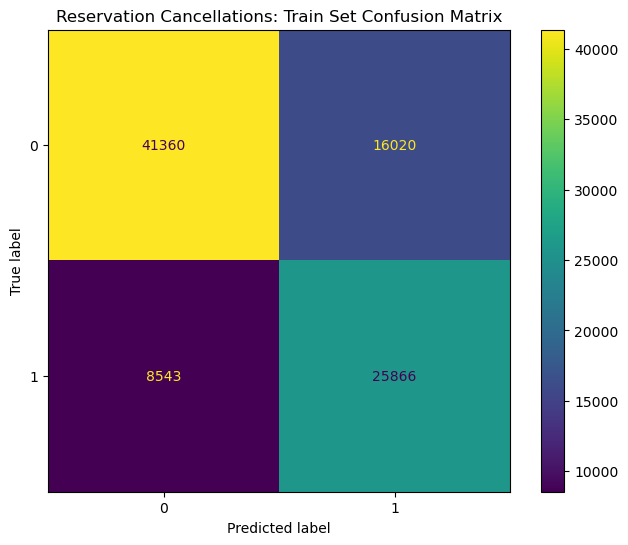

In [309]:
ConfusionMatrixDisplay.from_estimator(log_reg, X_train_scaled, y_train)

plt.title('Reservation Cancellations: Train Set Confusion Matrix')

plt.show()

/Users/brianlui/anaconda3/envs/rm_system/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


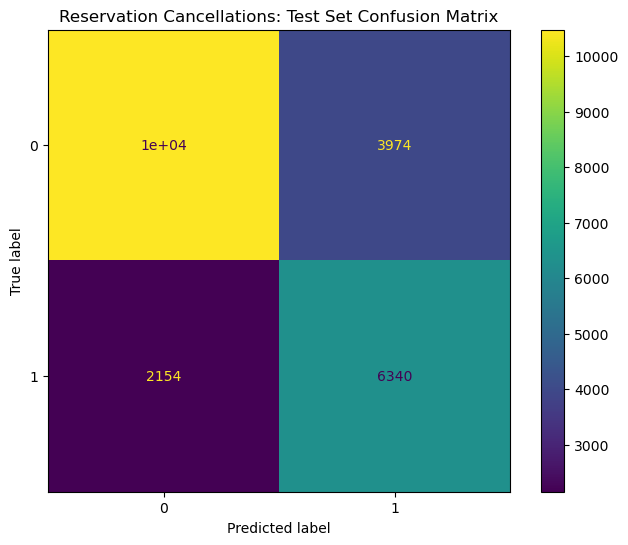

In [ ]:
ConfusionMatrixDisplay.from_estimator(log_reg, X_test_scaled, y_test)

plt.title('Reservation Cancellations: Test Set Confusion Matrix')
plt.show()

Based on the Test Set confusion matrix above:
- **True Negatives**: 10,000 of the data points from Class 0 were correctly predicted as reservations that would not cancel
- **False Positives**: about 4000 of the reservations that were predicted to cancel, actually did not cancel
- **False Negatives**: 2000 of the reservations that cancelled were missed by our model and predicted that they would not cancel
- **True Positives**: 6000 of the cancelled reservations were correctly identified by the model.

In [327]:
# Get class predictions
y_pred = log_reg.predict(X_test_scaled)

/Users/brianlui/anaconda3/envs/rm_system/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [325]:
initial_report = classification_report(y_test, y_pred)
print(initial_report)

              precision    recall  f1-score   support

           0       0.83      0.73      0.77     14454
           1       0.61      0.75      0.67      8494

    accuracy                           0.73     22948
   macro avg       0.72      0.74      0.72     22948
weighted avg       0.75      0.73      0.74     22948



The logistic regression model returned a f1 score of only 67%.  The classification report also returned an accuracy of only 73%.

**Precision**: Out of all the reservations that the model predicted to to cancel, only 61% actually canceled.

**Recall**: Out of all the reservations that cancelled, the model was able to predict 75% of them.

## Question 1: Why does the classification report return an accuracy of 73% where when I ran my original log_reg I returned a score of 95.5%?

In [313]:
# Checking coefficients values
pd.DataFrame({'coeff': log_reg.coef_[0]}, index=X_train.columns).sort_values('coeff')

,coeff
deposit_type_No Deposit,-1.561172
status_year,-0.812443
booking_changes,-0.794650
total_of_special_requests,-0.754253
market_segment_Offline TA/TO,-0.697127
required_car_parking_spaces,-0.691633
distribution_channel_Direct,-0.347170
market_segment_Direct,-0.336157
previous_bookings_not_canceled,-0.260051
stays_in_weekend_nights,-0.257508


Before exploring any additional tuning for logistic regression, I want to explore other models to see if their baseline performances are any better.

# Baseline Random Forest Model

In [329]:
# Instantiate random forest
random_forest = RandomForestClassifier(n_estimators=100) # instantiating and picking to train 100 DT models which is the default

# Fit the random forest model
random_forest.fit(X_train_scaled, y_train)

# Score Train and Test
print(f""" 
Train Score: {random_forest.score(X_train_scaled, y_train).round(3)}

Test Score: {random_forest.score(X_test_scaled, y_test).round(3)}

      """)

 
Train Score: 1.0

Test Score: 0.962

      


| Model           | Train Score | Test Score | n_estimators | max_depth | n_samples_sp |
|------------------|-------------|------------|--------------|-----------|--------------|
| random_forest    | 100%        | 96.20%     | 1000         | -         | -            |


## Question 3: Is it okay to jump right into grid search for hyperparameters? Or should I have tried to manually identify the best hyperparameters using loops?  If so, should I create samples?

## Grid Search for Random Forest Hyper Parameters


In [330]:
#Creating pipeline for grid search
rf_estimators = [('random_forest', RandomForestClassifier())]
rf_pipe = Pipeline(rf_estimators)

#hyperparameters to search
rf_params = {'random_forest__n_estimators': [50, 100, 150],
             'random_forest__max_depth': [2, 4, 6, 8],
             'random_forest__min_samples_split': [2, 5, 10]}

rf_grid_search = GridSearchCV(rf_pipe, param_grid=rf_params)

rf_fitted_search = rf_grid_search.fit(X_train_scaled, y_train)

In [331]:
print("Best Random Forest Parameters:", rf_grid_search.best_params_)
print("Best Cross-Validation Accuracy:", rf_grid_search.best_score_)

Best Random Forest Parameters: {'random_forest__max_depth': 8, 'random_forest__min_samples_split': 5, 'random_forest__n_estimators': 50}
Best Cross-Validation Accuracy: 0.8247502881368908


## Random Forest Model with Grid Searched HyperParameters

In [334]:
# Instantiate random forest
random_forest2 = RandomForestClassifier(n_estimators=50, max_depth=8, min_samples_split=5, random_state=24) 

# Fit the random forest model
random_forest2.fit(X_train_scaled, y_train)

# Score Train and Test
print(f""" 
Train Score: {random_forest2.score(X_train_scaled, y_train).round(3)}

Test Score: {random_forest2.score(X_test_scaled, y_test).round(3)}
      """)

 
Train Score: 0.825

Test Score: 0.827
      


| Model           | Train Score | Test Score | n_estimators | max_depth | n_samples_sp |
|------------------|-------------|------------|--------------|-----------|--------------|
| random_forest    | 100%        | 96.20%     | 1000         | -         | -            |
| random_forest2   | 82.50%      | 82.70%     | 500          | 8         | 5            |


The random forest model with the hyperparameters from the grid search are a lot more promising and are not overfitted.  I will take the random_forest2 model to evaluate the model further

## Confusion Matrix for Random Forest

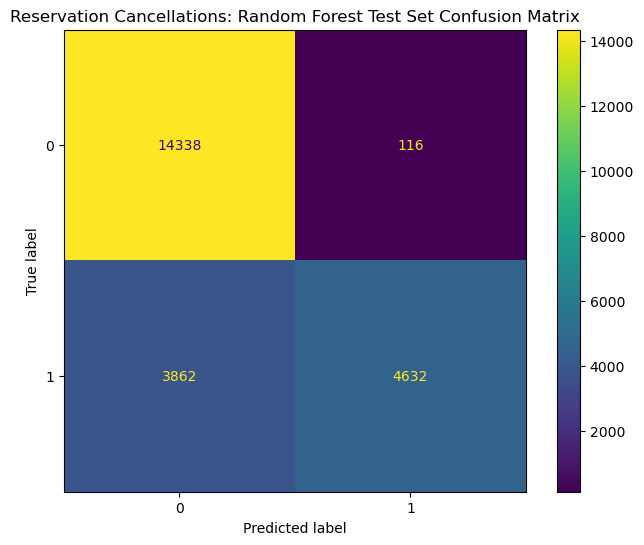

In [342]:
# Instantiate Confusion Matrix
ConfusionMatrixDisplay.from_estimator(random_forest2, X_test_scaled, y_test)

plt.title('Reservation Cancellations: Random Forest Test Set Confusion Matrix')
plt.show()

Based on the Test Set confusion matrix above:
- **True Negatives**: 14,000 of the data points from Class 0 were correctly predicted as reservations that would not cancel
- **False Positives**: only ~100 of the reservations that the model predicted to cancel, did not cancel
- **False Negatives**: 3800 of the reservations that cancelled were missed by our model and predicted that they would not cancel
- **True Positives**: 4600 of the cancelled reservations were correctly predicted out of the 8500 total cancellations

In [ ]:
# Get class predictions for random_forest2
y_pred_rf = random_forest2.predict(X_test_scaled)

rf_report = classification_report(y_test, y_pred_rf)
print(rf_report)

              precision    recall  f1-score   support

           0       0.79      0.99      0.88     14454
           1       0.98      0.55      0.70      8494

    accuracy                           0.83     22948
   macro avg       0.88      0.77      0.79     22948
weighted avg       0.86      0.83      0.81     22948



The f1-score of the random forest model is only 70%, with a Precision of 98% but a low recall of only 55%. Meaning out of all the cancellated reservations, the model was only able to predict 55% of them. The goal is to see if we can increase recall:
1. Add hyperparameter class_weight to evaluate changes to recall.
2. I will see if adjusting thresholds can bring a better balance and increase the f1 score.

In [ ]:
# Instantiate random forest3 with class_weight being balanced
random_forest3 = RandomForestClassifier(n_estimators=50, max_depth=8, min_samples_split=5, random_state=24, class_weight='balanced') 

# Fit the random forest model
random_forest3.fit(X_train_scaled, y_train)

# Score Train and Test
print(f""" 
Train Score: {random_forest3.score(X_train_scaled, y_train).round(3)}

Test Score: {random_forest3.score(X_test_scaled, y_test).round(3)}""")

 
Train Score: 0.862

Test Score: 0.861


In [340]:
# Get class predictions
y_pred_rf3 = random_forest3.predict(X_test_scaled)

rf3_report = classification_report(y_test, y_pred_rf3)
print(rf3_report)

              precision    recall  f1-score   support

           0       0.85      0.94      0.89     14454
           1       0.87      0.73      0.79      8494

    accuracy                           0.86     22948
   macro avg       0.86      0.83      0.84     22948
weighted avg       0.86      0.86      0.86     22948



| Model          | Train Score | Test Score | Recall | Precision | f1-score | n_estimators | max_depth | n_samples_split | class_weight |
|----------------|-------------|------------|--------|-----------|----------|--------------|-----------|-----------------|--------------|
| random_forest  | 100%        | 96.20%     |        |           |          | 1000         | -         | -               | -            |
| random_forest2 | 82.50%      | 82.70%     | 98%    | 55%       | 70%      | 500          | 8         | 5               | -            |
| random_forest3 | 86.20%      | 86.10%     | 87%    | 73%       | 79%      | 500          | 8         | 5               | balanced     |


Adding class weight to the random forest model increased **Precision** by 18% and decreased **Recall** by 11%, however provided an overall **f1-score** of 79% (increase of 9%).

## Question 2: After my random_forest2 model ran with a low precision, applying class_weight gave it a better balanced f1-score.  Should I still try to adjust the threshold? I feel like the 18% precision gain for a 11% recall loss was worth it and I feel happy with the results.

/Users/brianlui/anaconda3/envs/rm_system/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/brianlui/anaconda3/envs/rm_system/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/brianlui/anaconda3/envs/rm_system/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/brianlui/anaconda3/envs/rm_system/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defi

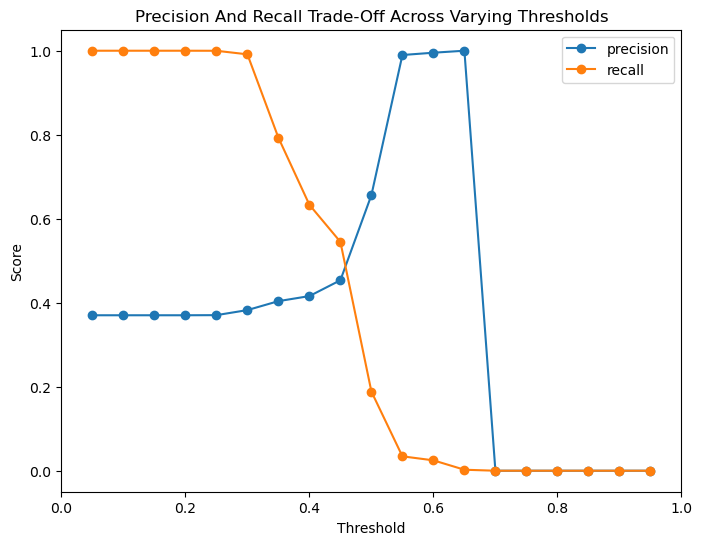

In [341]:
# Identify thresholds to maximize f1

# make probablistic predictions
y_proba_rf = random_forest3.predict_proba(X_test)[:, 1]

# Vary thresholds by 0.05 from 0.05 to 0.95
thresholds = np.arange(0.05, 1, 0.05)

precisions = list()
recalls = list()

for threshold in thresholds:
    # Apply threshold
    y_threshold = np.where(y_proba_rf > threshold, 1, 0)

    # Calculate precision and recall
    precision = precision_score(y_test, y_threshold)
    recall = recall_score(y_test, y_threshold)

    # Append to list
    precisions.append(precision)
    recalls.append(recall)

# Visualize the result
plt.figure()

plt.plot(thresholds, precisions, label="precision", marker="o")
plt.plot(thresholds, recalls, label="recall", marker="o")

plt.xlim(0, 1)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision And Recall Trade-Off Across Varying Thresholds")
plt.legend()

plt.show()


# Model Comparison

Next Steps:
1. ROC and AUC for log_reg
2. ROC and AUC for random_forest3

# Workspace

Manually identifying best hyperparameters for Random Forest Model

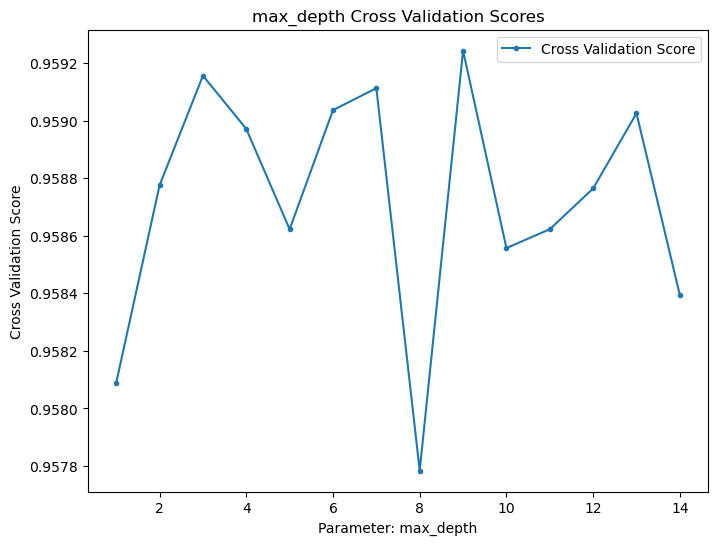

The best model has max_depth =  9


In [ ]:
# Manually identify best max_depth for Random Forest

#Creating empty lists to keep track of scores
rf_cv_scores = []

# Create an array of max_depth
depth_range = np.array(range(1,15), dtype=int)

# Loop
for depth in depth_range:
    # Instantiate model
    rf_model = RandomForestClassifier(max_depth=depth)
   
    # Fit to TRAINING set
    cv_score = np.mean(cross_val_score(random_forest, X_train_scaled, y_train, cv=5))

    # Score on TRAINING set
    rf_cv_scores.append(cv_score)

#Plot cross validation result
plt.figure()
plt.plot(depth_range, rf_cv_scores, label="Cross Validation Score", marker=".")

#plt.grid(alpha=0.1)
plt.xlabel("Parameter: max_depth")
plt.ylabel("Cross Validation Score")
plt.title("max_depth Cross Validation Scores")
plt.legend()
plt.show()

# Print the optimal max_depth
index_of_max = np.array(rf_cv_scores).argmax()
print("The best model has max_depth = ", depth_range[index_of_max])

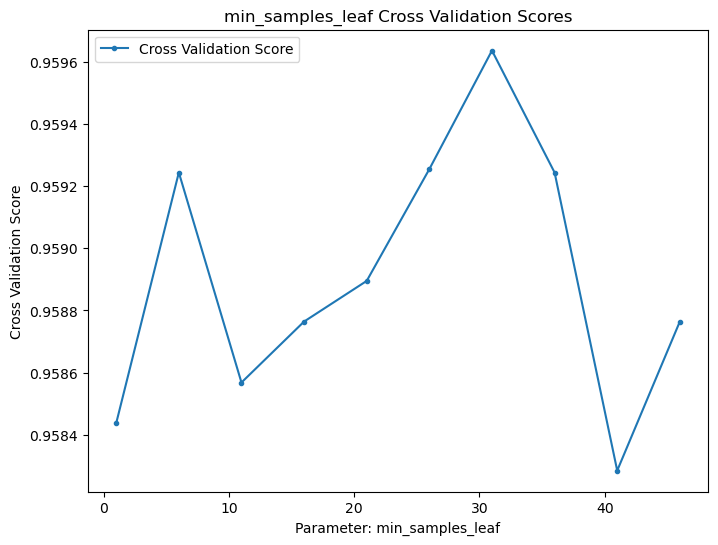

The best model has min_samples_leaf =  31


In [344]:
# Manually identify best min_samples_leaf for random forests

#Creating empty lists to keep track of csores
rf_cv_scores = []

# Create an array of min_samples_leaf
min_samples = np.array(range(1,50,5), dtype=int)

# Loop
for leaf in min_samples:
    # Instantiate model
    rf_model = RandomForestClassifier(min_samples_leaf=leaf)
   
    # Fit to TRAINING set
    cv_score = np.mean(cross_val_score(random_forest, X_train_scaled, y_train, cv=5))

    # Score on TRAINING set
    rf_cv_scores.append(cv_score)

#Plot cross validation result
plt.figure()
plt.plot(min_samples, rf_cv_scores, label="Cross Validation Score", marker=".")

#plt.grid(alpha=0.1)
plt.xlabel("Parameter: min_samples_leaf")
plt.ylabel("Cross Validation Score")
plt.title("min_samples_leaf Cross Validation Scores")
plt.legend()
plt.show()

# Print the optimal min_samples_leaf
index_of_max = np.array(rf_cv_scores).argmax()
print("The best model has min_samples_leaf = ", min_samples[index_of_max])

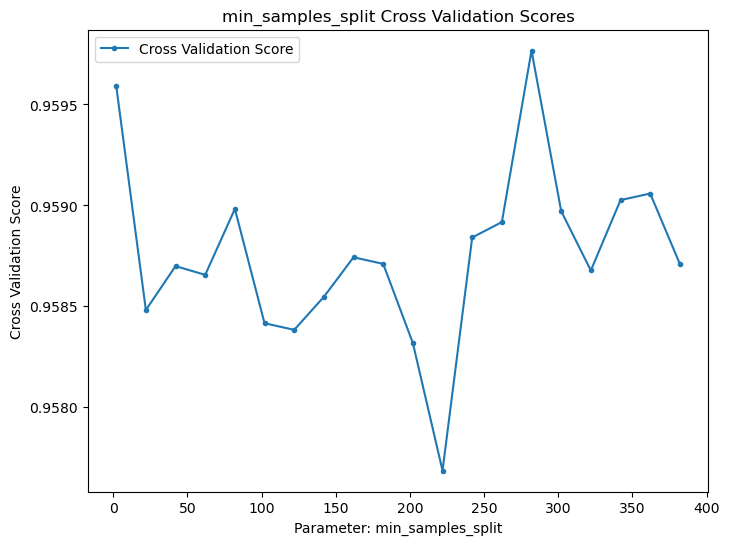

The best model has min_samples_split =  282


In [345]:
# Manually identify best min_samples_split

#Creating empty lists to keep track of csores
rf_cv_scores = []

# Create an array of min_samples_split
min_splits = np.array(range(2,400,20), dtype=int)

# Loop
for split in min_splits:
    # Instantiate model
    rf_model = RandomForestClassifier(min_samples_split=split)
   
    # Fit to TRAINING set
    cv_score = np.mean(cross_val_score(random_forest, X_train_scaled, y_train, cv=5))

    # Score on TRAINING set
    rf_cv_scores.append(cv_score)

#Plot cross validation result
plt.figure()
plt.plot(min_splits, rf_cv_scores, label="Cross Validation Score", marker=".")

#plt.grid(alpha=0.1)
plt.xlabel("Parameter: min_samples_split")
plt.ylabel("Cross Validation Score")
plt.title("min_samples_split Cross Validation Scores")
plt.legend()
plt.show()

# Print the optimal min_samples_split
index_of_max = np.array(rf_cv_scores).argmax()
print("The best model has min_samples_split = ", min_splits[index_of_max])

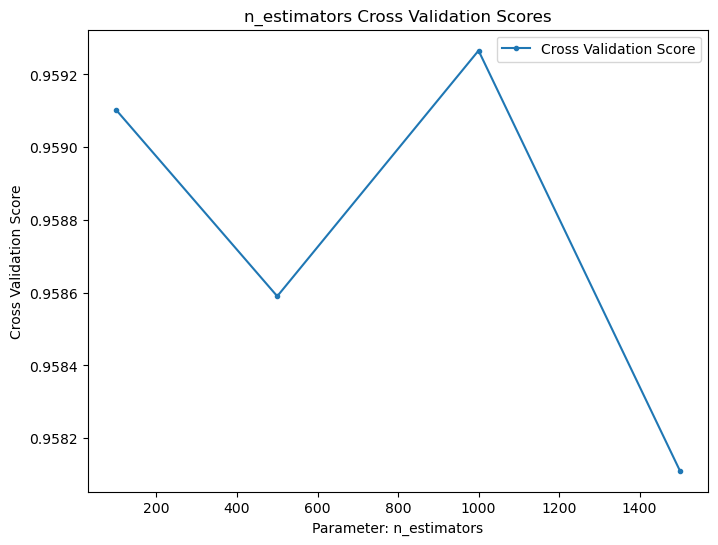

The best model has n_estimators =  1000


In [346]:
# Manually identify best n_estimators

#Creating empty lists to keep track of csores
rf_cv_scores = []

# Create an array of n_estimators
n_estimators = [100, 500, 1000, 1500]

# Loop
for n in n_estimators:
    # Instantiate model
    rf_model = RandomForestClassifier(n_estimators=n)
   
    # Fit to TRAINING set
    cv_score = np.mean(cross_val_score(random_forest, X_train_scaled, y_train, cv=5))

    # Score on TRAINING set
    rf_cv_scores.append(cv_score)

#Plot cross validation result
plt.figure()
plt.plot(n_estimators, rf_cv_scores, label="Cross Validation Score", marker=".")

#plt.grid(alpha=0.1)
plt.xlabel("Parameter: n_estimators")
plt.ylabel("Cross Validation Score")
plt.title("n_estimators Cross Validation Scores")
plt.legend()
plt.show()

# Print the optimal C
index_of_max = np.array(rf_cv_scores).argmax()
print("The best model has n_estimators = ", n_estimators[index_of_max])

## Hyperparameter optimization for C

In [314]:
# #Use Cross Validation to find the best C value

# # Store the results
# cross_validation_scores = []

# # Create an array of powers of ten for the values of inverse regularization strength C
# C_range = 10 ** np.array(range(-5, 5), dtype=float)

# # Perform cross validation
# for C in C_range:
#     model = LogisticRegression(C=C, random_state=24, max_iter=1000)

#     # The cross validation score (mean of scores from all folds)
#     cv_score = np.mean(cross_val_score(model, X_train_scaled, y_train, cv=5))

#     # Append the score
#     cross_validation_scores.append(cv_score)

# plt.figure(figsize=(5,3))
# plt.plot(C_range, cross_validation_scores, label="Cross Validation Score", marker=".")
# plt.xscale("log")
# plt.grid(alpha=0.1)
# plt.xlabel("Regularization Parameter: C")
# plt.ylabel("Cross Validation Score")
# plt.title("Cross Validation Scores")
# plt.legend()
# plt.show()

# # Print the optimal C
# index_of_max = np.array(cross_validation_scores).argmax()
# print("The best model has C = ", C_range[index_of_max])

Based on the the plot above using cross validation to obtain an optimal C hyperparameter, 10000 will be what I attempt to use next

## PCA with Log_Reg model
- Attempting PCA with the same hyperparameters as log_reg2 model with max iter of 1000 to see if model scores improve

In [315]:
# # Create the PCA object
# PCA_object = PCA()

# # Fit the PCA object to the data
# PCA_object.fit(X_train_scaled)

# # Transform the original data
# X_PCA_train = PCA_object.transform(X_train_scaled)
# X_PCA_test = PCA_object.transform(X_test_scaled)

In [316]:
## Instantiate
# log_reg4 = LogisticRegression(max_iter=1000)

# # Fit logreg model to X_train
# log_reg4.fit(X_PCA_train, y_train)

# # Scoring the logreg model
# print(f' Train score: {log_reg4.score(X_PCA_train, y_train)}')
# print(f' Test score: {log_reg4.score(X_PCA_test, y_test)}')

After applying PCA, the accuracies between train and test have dropped to ~99%

| Model    | Train Score | Test Score | Hyperparameter C | K-Fold Cross | PCA n_components |
|----------|-------------|------------|------------------|--------------|------------------|
| Log_Reg  | 100%        | 100%       |                  |              |                  |
| Log_Reg2 | 100%        | 100%       | C = 0.001        |       5      |                  |
| Log_Reg3 | 99.11%      | 99.03%     | C = 0.001        |              |        10        |



## Cancellation Days before arrival Feature engineering
- How many days before arrival do cancellations occur? For `reservation_status` that are 'Canceled' how many days between `reservation_status_date` and `arrival_date`?

Additional EDA: 
- Cancellation window by `market_segment`


In [317]:
# Value counts of reservation status
#clean_df['reservation_status'].value_counts()

In [318]:
# Calculate the difference between the arrival_date and reservation_status_date  
#clean_df['date_diff'] = (clean_df['arrival_date'] - clean_df['reservation_status_date']).dt.days # converting the results into an integer

In [319]:
# Sanity check
#clean_df['date_diff'].head(5)

In [320]:
# pull data where reservation_status == Canceled
#canceled_res = clean_df[clean_df['reservation_status']=='Canceled']

In [321]:
#canceled_res['date_diff'].describe()

The average date difference between a cancellation being made and the arrival date of the reservation is 88 days. 

In [322]:
# Value counts of date_diff to see the top 10 date differences with cancelled reservations
#canceled_res['date_diff'].value_counts().head(10)

The largest number of cancellations occur on the same day of arrival (881 cancellations)

In [323]:
# Date diff by market segment
#canceled_res.groupby(['market_segment', 'date_diff']).size().unstack(fill_value=0)


Many of the cancellations that are further out (400+ days) are groups. While majority of the cancellations within 10 days are with Online Travel Agents.